In [116]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [117]:
df = pd.read_excel(r'Emissionen_nach_sektoren.xlsx')
df

,Treibhausgasemissionen in Deutschland nach Sektoren des Klimaschutzgesetzes in den Jahren 1990 bis 2021 und Prognose für 2030 (in Millionen Tonnen CO2-Äquivalent),1990,2000,2010,2018,2019,2020,2021,2030¹
0,Energiewirtschaft,466.0,385.0,368.0,309.0,259.0,220.0,247.0,108.0
1,Industrie,284.0,208.0,188.0,190.0,183.0,172.0,181.0,118.0
2,Verkehr,164.0,181.0,153.0,163.0,164.0,146.0,148.0,85.0
3,Gebäude,210.0,167.0,149.0,116.0,121.0,119.0,115.0,67.0
4,Landwirtschaft,87.0,72.0,69.0,68.0,63.0,62.0,61.0,56.0
5,Abfallwirtschaft und Sonstiges,38.0,30.0,15.0,10.0,9.0,9.0,8.0,4.0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Treibhausgasemissionen des Industriesektors in...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Eisen und Stahl,NaN,NaN,NaN,NaN,NaN,NaN,35.4,NaN
9,Raffinerien,NaN,NaN,NaN,NaN,NaN,NaN,22.5,NaN


In [118]:
sectors2021 = df.iloc[0:6, [0, 7]]
industry2021 = df.iloc[8:, [0, 7]]

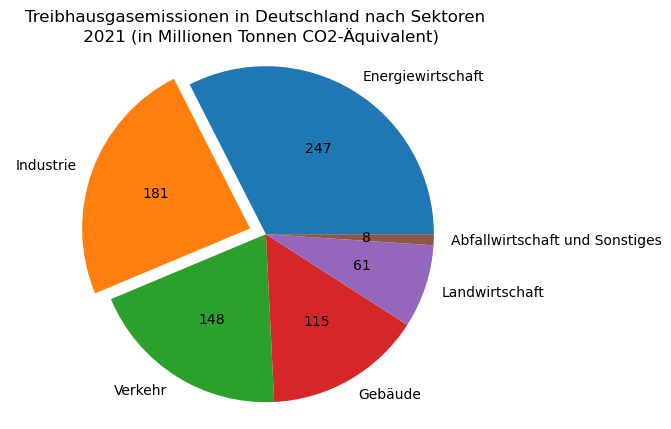

<Figure size 640x480 with 0 Axes>

In [119]:
# Plot
plt.pie(sectors2021["2021"], labels=sectors2021.iloc[:,0], autopct=lambda p: '{:.0f}'.format(p * sum(sectors2021["2021"]) / 100),
        explode = (0, 0.1, 0, 0,0,0)  # explode 1st slice
)
plt.axis('equal')
plt.title("Treibhausgasemissionen in Deutschland nach Sektoren \n 2021 (in Millionen Tonnen CO2-Äquivalent)")
plt.show()
plt.savefig('Sektoren.png')

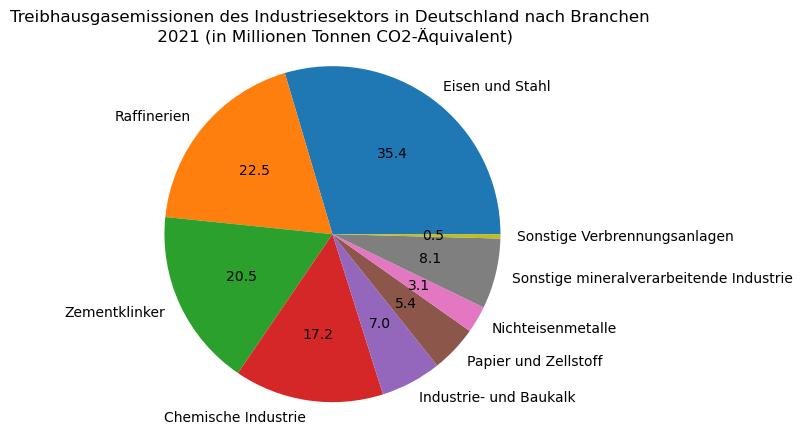

In [120]:
# Plot
plt.pie(industry2021["2021"], labels=industry2021.iloc[:,0], autopct=lambda p: '{:.1f}'.format(p * sum(industry2021["2021"]) / 100))
plt.axis('equal')
plt.title("Treibhausgasemissionen des Industriesektors in Deutschland nach Branchen \n 2021 (in Millionen Tonnen CO2-Äquivalent)")
plt.savefig('Branchen.png')

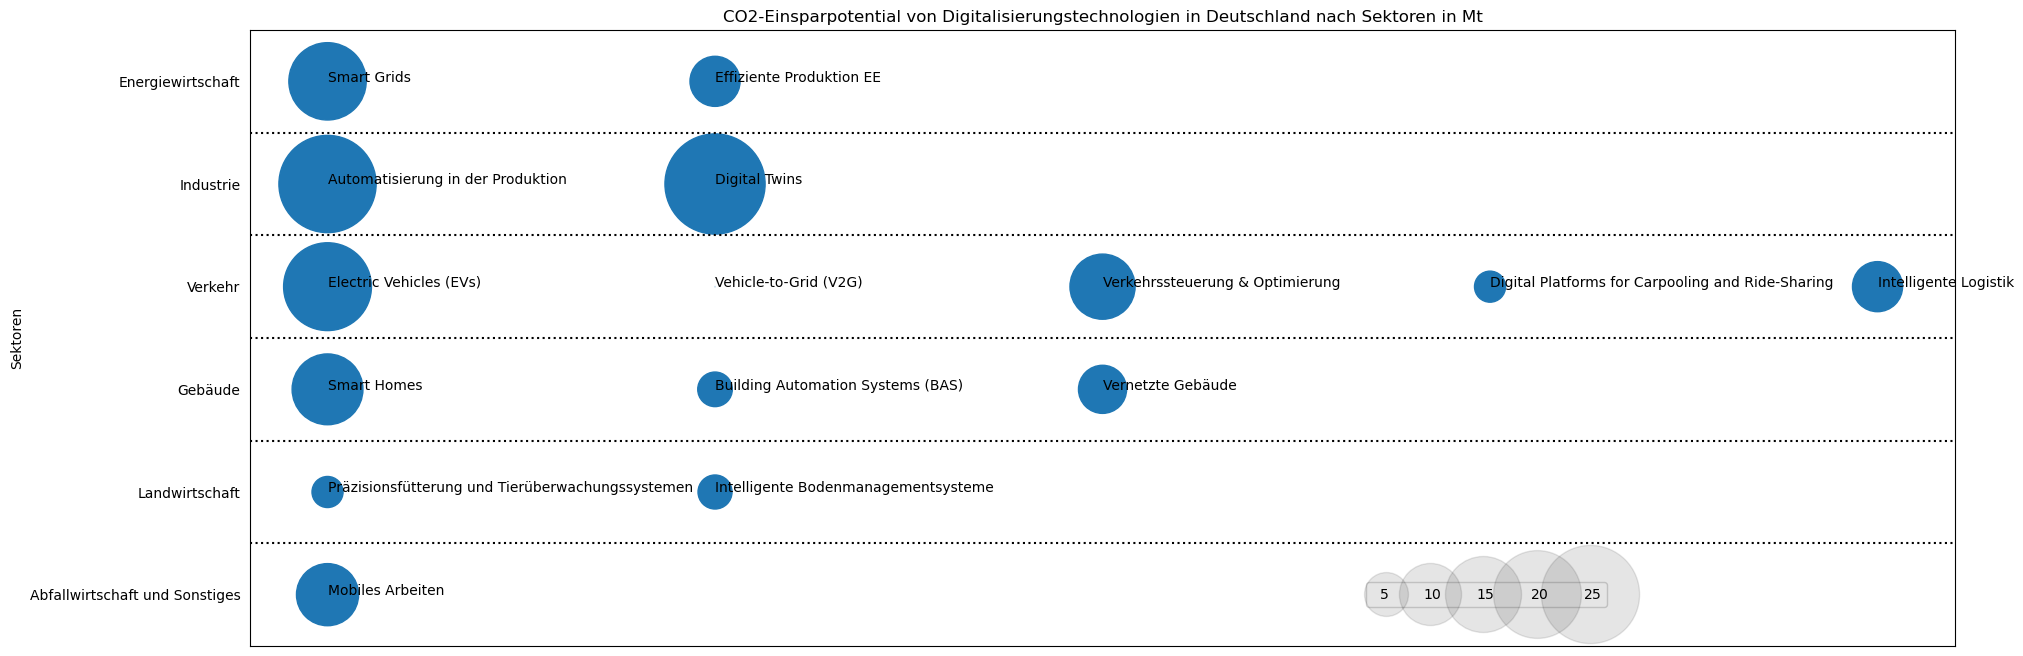

In [121]:
df2 = pd.read_excel(r'Emissionssparpotenzial.xlsx')
df2 = df2[df2["potentielle CO² Einsparung pro Jahr in Mt absolut durchschnitt"]>0]

plt.figure(figsize=(22,8))
plt.ylim([0, 6])

plt.title("CO2-Einsparpotential von Digitalisierungstechnologien in Deutschland nach Sektoren in Mt")
plt.ylabel("Sektoren")

loc = [0.5]

for s in range(1, len(sectors2021.iloc[:,0])):
    plt.axhline(y = s, color = 'black', linestyle = "dotted")
    loc.append(s+0.5)

sec2loc = dict(zip(sectors2021.iloc[:,0].iloc[::-1], loc))
sec_num = dict.fromkeys(sec2loc.keys(),0)

factor = 200

f = lambda a: (a*factor)      # function to calculate size from data
g = lambda s: s/factor # inverse function to calc. data from size

y = []
x = []
for index, row in df2.iterrows():
        y.append(sec2loc[row.Sektor])
        sec_num[row.Sektor] += 1
        x.append(sec_num[row.Sektor])

plt.yticks(loc, sectors2021.iloc[:,0].iloc[::-1])

sc = plt.scatter(x, y, s=f(df2["potentielle CO² Einsparung pro Jahr in Mt absolut durchschnitt"]))
plt.legend(*sc.legend_elements("sizes", num=6, alpha=0.1, func=g), ncol = 6, bbox_to_anchor=(0.8, 0.115), handletextpad=-1.5)

for i, txt in enumerate(df2["Technologie/Feld"]):
    plt.annotate(txt, (x[i], y[i]))
    
plt.xticks([])
plt.tick_params(left = False, bottom = False)
plt.show()

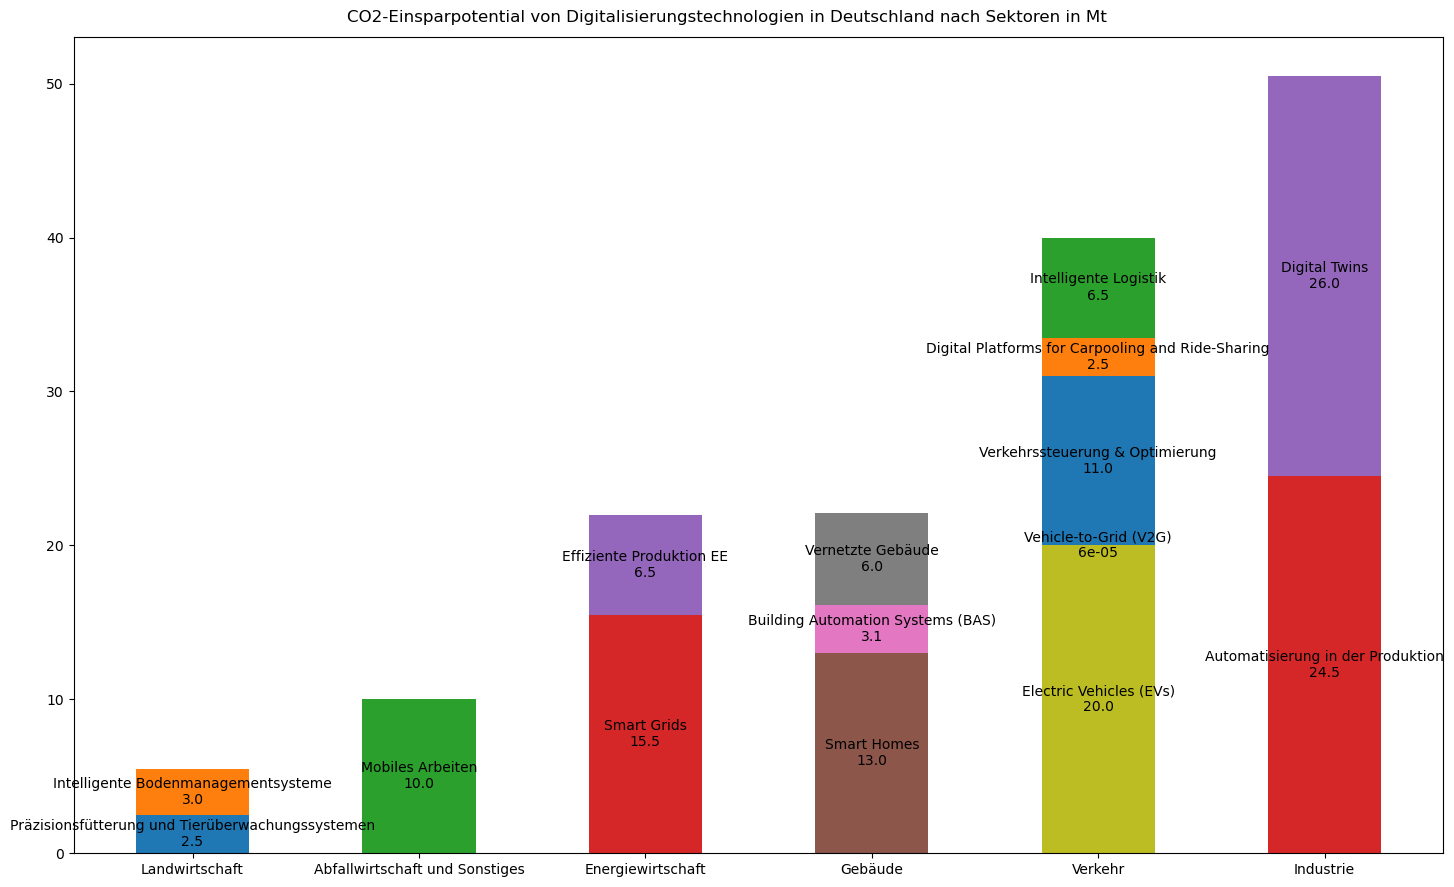

In [126]:
fig, ax = plt.subplots(figsize=(15, 9))
fig.suptitle("CO2-Einsparpotential von Digitalisierungstechnologien in Deutschland nach Sektoren in Mt")

for sektor in df2.groupby("Sektor")["potentielle CO² Einsparung pro Jahr in Mt absolut durchschnitt"].sum().sort_values().index:
    temp = df2[df2["Sektor"] == sektor]
    b = 0
    for index, row in temp.iterrows():
        value = row["potentielle CO² Einsparung pro Jahr in Mt absolut durchschnitt"]
        p = ax.bar(x = sektor, height = value, width=0.5, bottom = b)
        b += value
        ax.bar_label(p, labels = [row["Technologie/Feld"]+'\n'+ str(value)], label_type='center', fmt='blablabla')
plt.tight_layout()


In [123]:
df2

,Technologie/Feld,Beschreibung,Sektor,potentielle CO² Einsparung pro Jahr prozentual,potentielle CO² Einsparung pro Jahr in Mt absolut,potentielle CO² Einsparung pro Jahr in Mt absolut durchschnitt,Quelle
0,Electric Vehicles (EVs),Electric Vehicles (EVs): The widespread adopti...,Verkehr,NaN,20,20.00000,https://www.agora-verkehrswende.de/fileadmin/P...
1,Vehicle-to-Grid (V2G),Vehicle-to-Grid (V2G) Technology: V2G enables ...,Verkehr,NaN,"0,00006",0.00006,https://www.chademo.com/economic-benefits-and-...
2,Mobiles Arbeiten,Mobiles Arbeiten,Abfallwirtschaft und Sonstiges,NaN,9-11,10.00000,https://www.bitkom.org/sites/main/files/2021-1...
3,Verkehrssteuerung & Optimierung,Verkehrssteuerung & Optimierung,Verkehr,NaN,9-13,11.00000,https://www.bitkom.org/sites/main/files/2021-1...
4,Smart Homes,Smart Homes,Gebäude,NaN,14-12,13.00000,https://www.bitkom.org/sites/main/files/2021-1...
5,Smart Grids,Smart Grids: Smart grids integrate digital tec...,Energiewirtschaft,18,17-14,15.50000,https://www.pnnl.gov/main/publications/externa...
6,Präzisionsfütterung und Tierüberwachungssystemen,Präzisionsfütterung und Tierüberwachungssystemen,Landwirtschaft,NaN,2-3,2.50000,https://www.bitkom.org/sites/main/files/2021-1...
7,Digital Platforms for Carpooling and Ride-Sharing,Digital Platforms for Carpooling and Ride-Shar...,Verkehr,NaN,1-4,2.50000,https://www.bitkom.org/sites/main/files/2021-1...
8,Automatisierung in der Produktion,Automatisierung in der Produktion,Industrie,NaN,18-31,24.50000,https://www.bitkom.org/sites/main/files/2021-1...
9,Digital Twins,Digital Twins: Digital twins are virtual repli...,Industrie,NaN,26,26.00000,https://www.bitkom.org/sites/main/files/2021-1...
